Shape: (45211, 17)
y
no     39922
yes     5289
Name: count, dtype: int64

y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Missing values in the whole dataset: 0


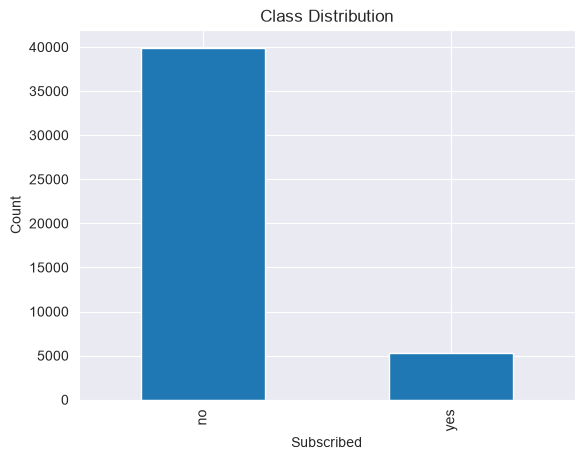

Features after one-hot encoding: 51
Train: (36168, 51)  Test: (9043, 51)

Class balance in the training set (still imbalanced at this point):
y
0    0.883
1    0.117
Name: proportion, dtype: float64
Best baseline decision tree: max_depth = 9

              precision    recall  f1-score   support

          no       0.93      0.96      0.94      7985
         yes       0.61      0.42      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



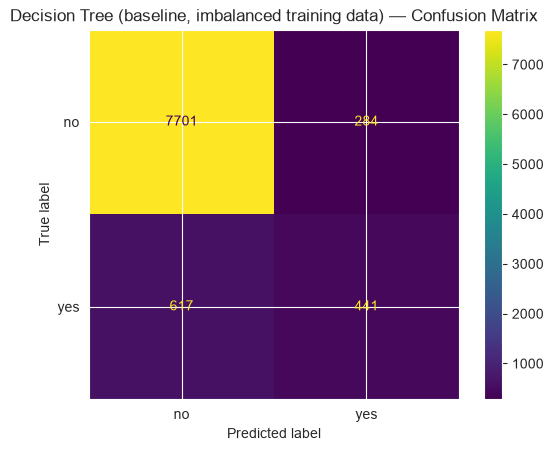

Best baseline neural network: hidden_layer_sizes = (32, 16)

              precision    recall  f1-score   support

          no       0.94      0.96      0.95      7985
         yes       0.61      0.50      0.55      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.73      0.75      9043
weighted avg       0.90      0.90      0.90      9043



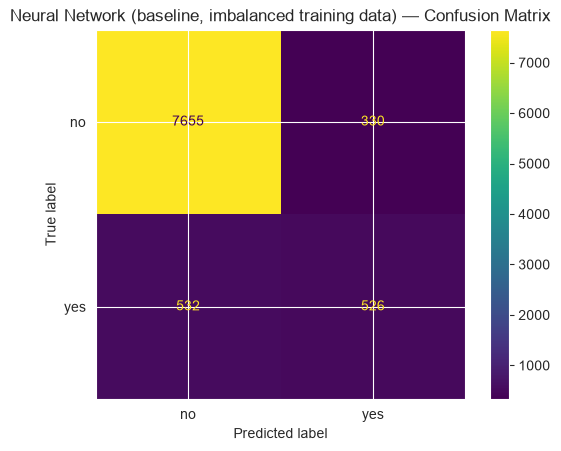

Both baseline models were trained directly on the imbalanced training set
(88% "no" / 12% "yes"). Accuracy looks strong, but check the Recall column —
that is the fraction of actual "yes" clients each model successfully identifies:
Balanced training set class counts:
y
1    31937
0    31937
Name: count, dtype: int64
Best decision tree (balanced training data): max_depth = 9

              precision    recall  f1-score   support

          no       0.98      0.81      0.89      7985
         yes       0.37      0.85      0.52      1058

    accuracy                           0.81      9043
   macro avg       0.67      0.83      0.70      9043
weighted avg       0.90      0.81      0.84      9043



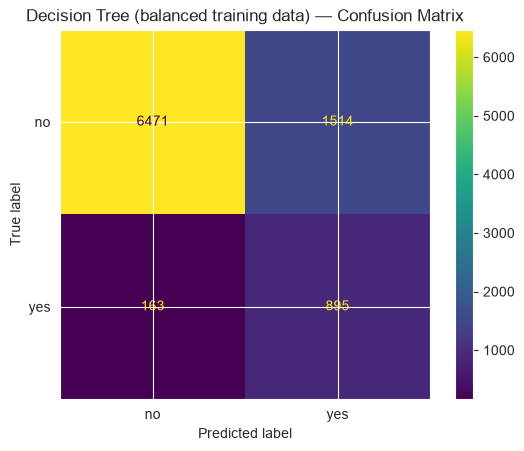

Best neural network (balanced training data): hidden_layer_sizes = (32, 16)

              precision    recall  f1-score   support

          no       0.97      0.86      0.91      7985
         yes       0.44      0.83      0.58      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.85      0.74      9043
weighted avg       0.91      0.86      0.87      9043



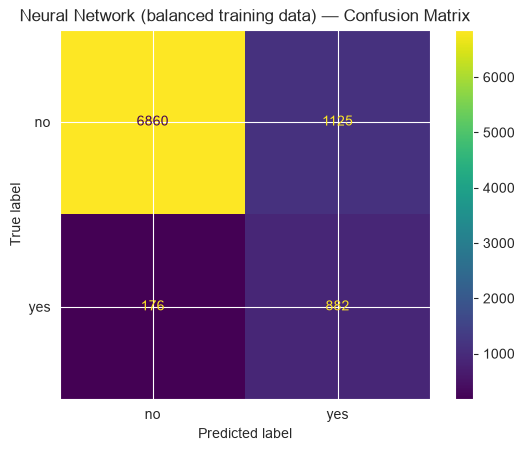

Baseline (imbalanced training data) vs balanced (oversampled training data):
                           Accuracy  Precision  Recall     F1  ROC-AUC
Decision Tree (baseline)      0.900      0.608   0.417  0.495    0.852
Decision Tree (balanced)      0.815      0.372   0.846  0.516    0.873
Neural Network (baseline)     0.905      0.614   0.497  0.550    0.923
Neural Network (balanced)     0.856      0.439   0.834  0.576    0.919

Recall on "yes" class:
  Decision Tree:   0.417 -> 0.846
  Neural Network:  0.497 -> 0.834


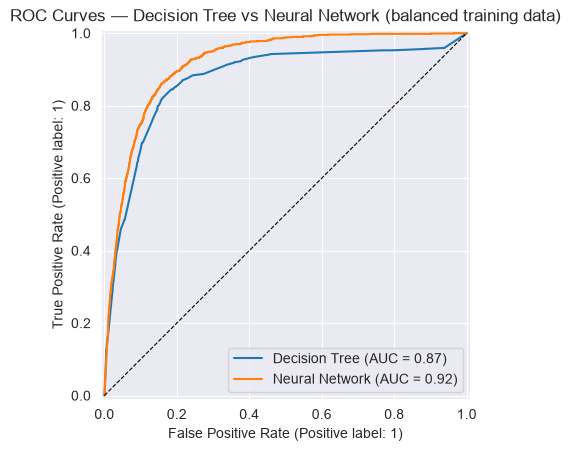

,Accuracy,Precision,Recall,F1,ROC-AUC
Decision Tree,0.815,0.372,0.846,0.516,0.873
Neural Network,0.856,0.439,0.834,0.576,0.919


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_STATE = 42  # fixed seed so every run gives the same results

# --- Load the dataset ---
df = pd.read_csv('bank-full.csv', sep=';')
print('Shape:', df.shape)
df.head()

# --- EDA recap ---
print(df['y'].value_counts())
print()
print(df['y'].value_counts(normalize=True).round(3))
print()
print('Missing values in the whole dataset:', df.isna().sum().sum())

df['y'].value_counts().plot(kind='bar', title='Class Distribution', xlabel='Subscribed', ylabel='Count')
plt.show()

# --- Data preparation encode target, encode, split, scale ---
# 1. target: yes -> 1, no -> 0
df['y'] = (df['y'] == 'yes').astype(int)

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 2. encode every categorical column
X = pd.get_dummies(df.drop(columns='y'))
y = df['y']
print('Features after one-hot encoding:', X.shape[1])

# 3. train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# 4. numeric features fit on train only
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Train:', X_train.shape, ' Test:', X_test.shape)
print()
print('Class balance in the training set (still imbalanced at this point):')
print(y_train.value_counts(normalize=True).round(3))

# --- Evaluation helper ---
def evaluate(model):
    """Return a dict of test-set metrics for a fitted model."""
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {'Accuracy':  accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall':    recall_score(y_test, pred),
            'F1':        f1_score(y_test, pred),
            'ROC-AUC':   roc_auc_score(y_test, proba)}